# Práctica Análisis de Centralidad de Nodos <img src="http://www.ubu.es/sites/default/files/portal_page/images/logo_color_2l_dcha.jpg" height="75" align="right"/>

## Autores
> Roberto Iturralde Zarzo <br/>
> Rubén Castañeda Matute

In [1]:
# Aquí importamos las librerias necesarias para este proyecto
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from assignment import net_ranking
import warnings
warnings.filterwarnings('ignore') # Para evitar advertencias visuales

### 2.1. Red de football 1998
Esta red dirigida representa a los países del Mundial del 98. Un arco de A hacia B indica que jugadores de A juegan (son exportados) en equipos de B.

**Métricas elegidas:**
* **In-degree centrality (Centralidad de grado de entrada):** Mide la cantidad de países desde los que una nación "importa" jugadores. Un alto grado de entrada señala a las ligas más atractivas o poderosas (países receptores de talento).
* **Out-degree centrality (Centralidad de grado de salida):** Mide a cuántos países diferentes exporta jugadores una nación.
* **PageRank:** Identifica los "sumideros" de talento más prestigiosos. Si ligas importantes importan tus jugadores, el país de destino adquiere mayor centralidad en la red.

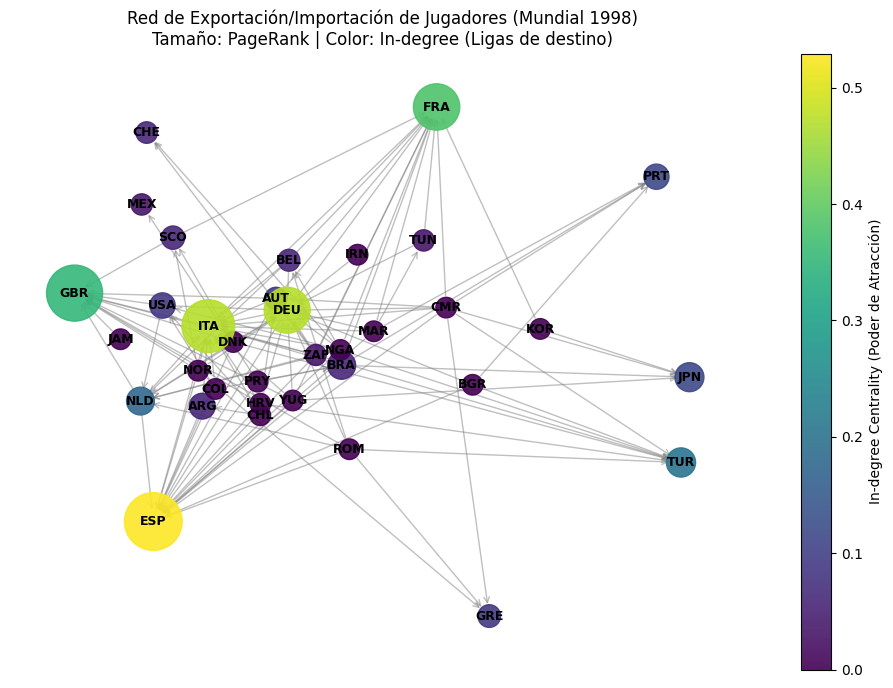

,País,PageRank
11,ESP,0.115385
13,GBR,0.108579
17,ITA,0.096262
12,FRA,0.074257
9,DEU,0.073057


In [2]:
# Aquí cargamos la red (formato Pajek)
# Nota: Pajek usa MultiDiGraph por defecto en NetworkX, lo convertimos a DiGraph para PageRank
G_football_multi = nx.read_pajek('dataset/football98.net')
G_football = nx.DiGraph(G_football_multi)

# Aquí calculamos las métricas
in_degree = nx.in_degree_centrality(G_football)
out_degree = nx.out_degree_centrality(G_football)
pagerank_foot = nx.pagerank(G_football)

# Aquí asignamos PageRank como atributo para visualizar
nx.set_node_attributes(G_football, pagerank_foot, 'pagerank')

# Aquí hacemos la visualización
plt.figure(figsize=(12, 8))

# Aquí gestionamos el tamaño del nodo el cuál dependerá de su PageRank (Multiplicado para que sea visible)
node_sizes = [v * 15000 for v in pagerank_foot.values()]
# Aquí gestionamos el color el cuál dependerá del In-degree (Recepción de jugadores)
node_colors = list(in_degree.values())

pos = nx.spring_layout(G_football, seed=42, k=0.5)

nodes = nx.draw_networkx_nodes(G_football, pos, node_size=node_sizes, 
                               node_color=node_colors, cmap=plt.cm.viridis, alpha=0.9)
nx.draw_networkx_edges(G_football, pos, arrowstyle='->', arrowsize=10, 
                       edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G_football, pos, font_size=9, font_weight="bold", font_color="black")

plt.title('Red de Exportación/Importación de Jugadores (Mundial 1998)\nTamaño: PageRank | Color: In-degree (Ligas de destino)')
plt.colorbar(nodes, label="In-degree Centrality (Poder de Atracción)")
plt.axis('off')
plt.show()

# Aquí vemos los Top 5 países más influyentes como receptores (PageRank)
import pandas as pd
df_foot = pd.DataFrame({'País': list(G_football.nodes()), 'PageRank': list(pagerank_foot.values())})
display(df_foot.sort_values(by='PageRank', ascending=False).head())

**Interpretación de resultados (Football 98):**
Como se observa en el gráfico y la tabla, países europeos como Inglaterra (GBR), España (ESP) e Italia (ITA) dominan tanto en *In-degree* como en *PageRank*. Esto refleja la realidad futbolística: sus ligas actúan como los principales destinos (sumideros) del talento mundial. Nodos más pequeños y claros representan países exportadores, cuyas selecciones están formadas por jugadores que militan en estas grandes ligas extranjeras.

### 2.2. Red de familias florentinas del renacimiento
Esta red muestra los enlaces matrimoniales en la Florencia del s. XV.

**Métricas elegidas:**
* **Betweenness Centrality (Intermediación):** Es fundamental en esta red histórica porque mide qué familias actúan como "puentes" entre otras que no están conectadas directamente. En la política renacentista, controlar las conexiones (información, alianzas) otorgaba un inmenso poder.

,node_id,pagerank,betweenness,average_index
0,Medici,0.145818,0.521978,1.000000
1,Guadagni,0.098399,0.254579,0.487719
2,Albizzi,0.079122,0.212454,0.407018
3,Salviati,0.061303,0.142857,0.273684
4,Ridolfi,0.069574,0.113553,0.217544


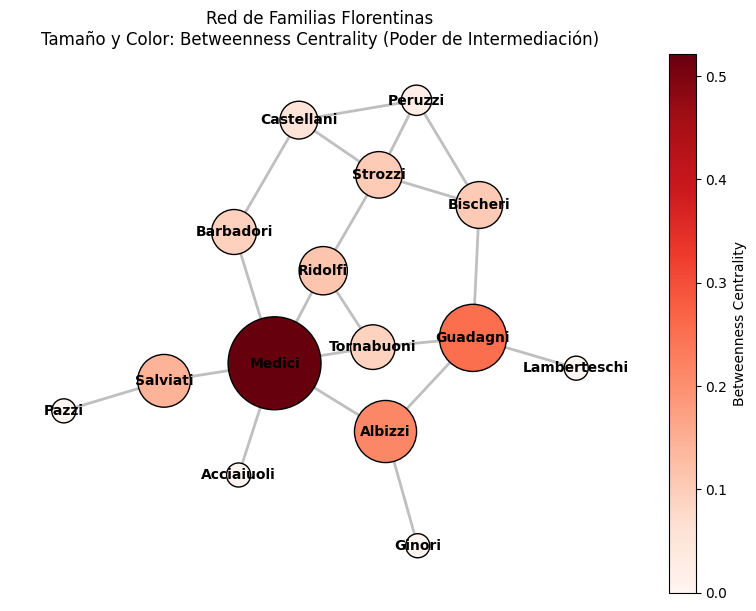

In [3]:
# Aquí cargamos la red
G_florentine = nx.florentine_families_graph()

# Aquí usamos la función creada en assignment.py (Dando 100% peso a Betweenness para este análisis)
df_florentine = net_ranking(G_florentine, (0.0, 1.0))
display(df_florentine.head())

# Aquí calculamos Betweenness para asignarlo como atributo visual
betweenness_flor = nx.betweenness_centrality(G_florentine)
nx.set_node_attributes(G_florentine, betweenness_flor, 'betweenness')

# Aquí hacemos la visualización
plt.figure(figsize=(10, 7))

# Aquí gestionamos el tamaño y el color basados en la intermediación
node_sizes_flor = [v * 8000 + 300 for v in betweenness_flor.values()]
node_colors_flor = list(betweenness_flor.values())

pos_flor = nx.kamada_kawai_layout(G_florentine)

nodes_flor = nx.draw_networkx_nodes(G_florentine, pos_flor, node_size=node_sizes_flor, 
                                    node_color=node_colors_flor, cmap=plt.cm.Reds, edgecolors='black')
nx.draw_networkx_edges(G_florentine, pos_flor, width=2, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G_florentine, pos_flor, font_size=10, font_weight="bold", font_family="sans-serif")

plt.title('Red de Familias Florentinas\nTamaño y Color: Betweenness Centrality (Poder de Intermediación)')
plt.colorbar(nodes_flor, label="Betweenness Centrality")
plt.axis('off')
plt.show()

**Interpretación de resultados (Familias Florentinas):**
El análisis revela claramente por qué la familia **Medici** alcanzó tanto poder frente a sus rivales, como los **Pazzi** (quienes intentaron derrocarlos). 
Aunque los Pazzi tenían algo de riqueza, los Medici poseen el valor de *Betweenness Centrality* más alto con mucha diferencia. Actúan como el "hub" central de la red, siendo la principal vía de conexión matrimonial entre familias periféricas que, de otro modo, estarían aisladas. Esta posición estructural de intermediación les otorgó un control sin igual sobre el flujo de alianzas e información.